In [ ]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, SimpleRNN, Dense
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
!pip install pyarabic -q
import pyarabic.araby as araby
from string import punctuation as ascii_punct
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Bidirectional, Dropout
!pip install wordcloud arabic_reshaper python-bidi -q
!wget -q https://github.com/google/fonts/raw/main/ofl/amiri/Amiri-Regular.ttf -O Amiri-Regular.ttf
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 9.4 MB/s eta 0:00:00


In [ ]:
df = pd.read_excel("Arabic Sentiment Analysis.xlsx")

In [ ]:
df.head()

,review_description,rating
0,شركه زباله و سواقين بتبرشم و مفيش حتي رقم للشك...,-1
1,خدمة الدفع عن طريق الكي نت توقفت عندي اصبح فقط...,1
2,تطبيق غبي و جاري حذفه ، عاملين اكواد خصم و لما...,-1
3,فعلا تطبيق ممتاز بس لو فى امكانية يتيح لمستخدم...,1
4,سيء جدا ، اسعار رسوم التوصيل لا تمت للواقع ب ص...,-1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32036 entries, 0 to 32035
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_description  32036 non-null  object
 1   rating              32036 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 500.7+ KB


In [ ]:
df.isnull().sum()

,0
review_description,0
rating,0


In [ ]:
df["rating"].value_counts()

,count
rating,
1,19189
-1,11340
0,1507


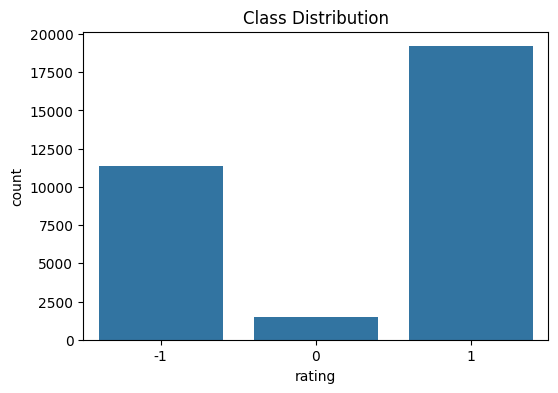

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="rating", data=df)

plt.title("Class Distribution")
plt.show()

#Part 2 – Arabic Text Preprocessing

check for stop words in the data

In [ ]:
arabic_stopwords = stopwords.words("arabic")
len(arabic_stopwords)

754

In [ ]:
df['stop_words'] = df['review_description'].apply(lambda x: len(set(x.split()) & set(arabic_stopwords)))
df.stop_words.value_counts()

,count
stop_words,
0,15636
1,7146
2,3783
3,2170
4,1249
5,735
6,463
7,279
8,186


In [ ]:
print(type(arabic_stopwords))
print(len(arabic_stopwords))
print(arabic_stopwords[:10])

<class 'list'>
754
['إذ', 'إذا', 'إذما', 'إذن', 'أف', 'أقل', 'أكثر', 'ألا', 'إلا', 'التي']


In [ ]:
negations = {
    "لا",
    "ليس",
    "لم",
    "لن",
    "ما",
    "غير",
    "بدون",
    "ولا",
    "مو",
    "مش",
    "وما"
}

original_set = set(arabic_stopwords)
custom_stopwords = original_set - negations

print("Original list length:", len(arabic_stopwords))
print("Original set length:", len(original_set))
print("Custom set length:", len(custom_stopwords))
print("Words removed:", sorted(original_set - custom_stopwords))

Original list length: 754
Original set length: 701
Custom set length: 693
Words removed: ['غير', 'لا', 'لم', 'لن', 'ليس', 'ما', 'ولا', 'وما']


In [ ]:
# Count unique non-negation stopwords and negation words in each review
df["non_negation_stopwords"] = df["review_description"].apply(
    lambda x: len(set(str(x).split()) & custom_stopwords)
)

df["negation_stopwords"] = df["review_description"].apply(
    lambda x: len(set(str(x).split()) & negations)
)

# Display distributions
print("Non-negation stopwords:")
print(df["non_negation_stopwords"].value_counts().sort_index())

print("\nNegation stopwords:")
print(df["negation_stopwords"].value_counts().sort_index())

Non-negation stopwords:
non_negation_stopwords
0     16964
1      7157
2      3557
3      1898
4       983
5       567
6       353
7       182
8       135
9        76
10       58
11       37
12       27
13       13
14       12
15        6
16        3
17        2
18        1
19        1
21        1
25        1
29        1
32        1
Name: count, dtype: int64

Negation stopwords:
negation_stopwords
0    25190
1     5424
2     1136
3      242
4       39
5        5
Name: count, dtype: int64


In [ ]:
emojis = {
    "🙂":"يبتسم",
    "😂":"يضحك",
    "💔":"قلب حزين",
    "🙂":"يبتسم",
    "❤️":"حب",
    "❤":"حب",
    "😍":"حب",
    "😭":"يبكي",
    "😢":"حزن",
    "😔":"حزن",
    "♥":"حب",
    "💜":"حب",
    "😅":"يضحك",
    "🙁":"حزين",
    "💕":"حب",
    "💙":"حب",
    "😞":"حزين",
    "😊":"سعادة",
    "👏":"يصفق",
    "👌":"احسنت",
    "😴":"ينام",
    "😀":"يضحك",
    "😌":"حزين",
    "🌹":"وردة",
    "🙈":"حب",
    "😄":"يضحك",
    "😐":"محايد",
    "✌":"منتصر",
    "✨":"نجمه",
    "🤔":"تفكير",
    "😏":"يستهزء",
    "😒":"يستهزء",
    "🙄":"ملل",
    "😕":"عصبية",
    "😃":"يضحك",
    "🌸":"وردة",
    "😓":"حزن",
    "💞":"حب",
    "💗":"حب",
    "😑":"منزعج",
    "💭":"تفكير",
    "😎":"ثقة",
    "💛":"حب",
    "😩":"حزين",
    "💪":"عضلات",
    "👍":"موافق",
    "🙏🏻":"رجاء طلب",
    "😳":"مصدوم",
    "👏🏼":"تصفيق",
    "🎶":"موسيقي",
    "🌚":"صمت",
    "💚":"حب",
    "🙏":"رجاء طلب",
    "💘":"حب",
    "🍃":"سلام",
    "☺":"يضحك",
    "🐸":"ضفدع",
    "😶":"مصدوم",
    "✌️":"مرح",
    "✋🏻":"توقف",
    "😉":"غمزة",
    "🌷":"حب",
    "🙃":"مبتسم",
    "😫":"حزين",
    "😨":"مصدوم",
    "🎼 ":"موسيقي",
    "🍁":"مرح",
    "🍂":"مرح",
    "💟":"حب",
    "😪":"حزن",
    "😆":"يضحك",
    "😣":"استياء",
    "☺️":"حب",
    "😱":"كارثة",
    "😁":"يضحك",
    "😖":"استياء",
    "🏃🏼":"يجري",
    "😡":"غضب",
    "🚶":"يسير",
    "🤕":"مرض",
    "‼️":"تعجب",
    "🕊":"طائر",
    "👌🏻":"احسنت",
    "❣":"حب",
    "🙊":"مصدوم",
    "💃":"سعادة مرح",
    "💃🏼":"سعادة مرح",
    "😜":"مرح",
    "👊":"ضربة",
    "😟":"استياء",
    "💖":"حب",
    "😥":"حزن",
    "🎻":"موسيقي",
    "✒":"يكتب",
    "🚶🏻":"يسير",
    "💎":"الماظ",
    "😷":"وباء مرض",
    "☝":"واحد",
    "🚬":"تدخين",
    "💐" : "ورد",
    "🌞" : "شمس",
    "👆" : "الاول",
    "⚠️" :"تحذير",
    "🤗" : "احتواء",
    "✖️": "غلط",
    "📍"  : "مكان",
    "👸" : "ملكه",
    "👑" : "تاج",
    "✔️" : "صح",
    "💌": "قلب",
    "😲" : "مندهش",
    "💦": "ماء",
    "🚫" : "خطا",
    "👏🏻" : "برافو",
    "🏊" :"يسبح",
    "👍🏻": "تمام",
    "⭕️" :"دائره كبيره",
    "🎷" : "ساكسفون",
    "👋": "تلويح باليد",
    "✌🏼": "علامه النصر",
    "🌝":"مبتسم",
    "➿"  : "عقده مزدوجه",
    "💪🏼" : "قوي",
    "📩":  "تواصل معي",
    "☕️": "قهوه",
    "😧" : "قلق و صدمة",
    "🗨": "رسالة",
    "❗️" :"تعجب",
    "🙆🏻": "اشاره موافقه",
    "👯" :"اخوات",
    "©" :  "رمز",
    "👵🏽" :"سيده عجوزه",
    "🐣": "كتكوت",
    "🙌": "تشجيع",
    "🙇": "شخص ينحني",
    "👐🏽":"ايدي مفتوحه",
    "👌🏽": "بالظبط",
    "⁉️" : "استنكار",
    "⚽️": "كوره",
    "🕶" :"حب",
    "🎈" :"بالون",
    "🎀":    "ورده",
    "💵":  "فلوس",
    "😋":  "جائع",
    "😛":  "يغيظ",
    "😠":  "غاضب",
    "✍🏻":  "يكتب",
    "🌾":  "ارز",
    "👣":  "اثر قدمين",
    "❌":"رفض",
    "🍟":"طعام",
    "👬":"صداقة",
    "🐰":"ارنب",
    "☂":"مطر",
    "⚜":"مملكة فرنسا",
    "🐑":"خروف",
    "🗣":"صوت مرتفع",
    "👌🏼":"احسنت",
    "☘":"مرح",
    "😮":"صدمة",
    "😦":"قلق",
    "⭕":"الحق",
    "✏️":"قلم",
    "ℹ":"معلومات",
    "🙍🏻":"رفض",
    "⚪️":"نضارة نقاء",
    "🐤":"حزن",
    "💫":"مرح",
    "💝":"حب",
    "🍔":"طعام",
    "❤︎":"حب",
    "✈️":"سفر",
    "🏃🏻‍♀️":"يسير",
    "🍳":"ذكر",
    "🎤":"مايك غناء",
    "🎾":"كره",
    "🐔":"دجاجة",
    "🙋":"سؤال",
    "📮":"بحر",
    "💉":"دواء",
    "🙏🏼":"رجاء طلب",
    "💂🏿 ":"حارس",
    "🎬":"سينما",
    "♦️":"مرح",
    "💡":"قكرة",
    "‼":"تعجب",
    "👼":"طفل",
    "🔑":"مفتاح",
    "♥️":"حب",
    "🕋":"كعبة",
    "🐓":"دجاجة",
    "💩":"معترض",
    "👽":"فضائي",
    "☔️":"مطر",
    "🍷":"عصير",
    "🌟":"نجمة",
    "☁️":"سحب",
    "👃":"معترض",
    "🌺":"مرح",
    "🔪":"سكينة",
    "♨":"سخونية",
    "👊🏼":"ضرب",
    "✏":"قلم",
    "🚶🏾‍♀️":"يسير",
    "👊":"ضربة",
    "◾️":"وقف",
    "😚":"حب",
    "🔸":"مرح",
    "👎🏻":"لا يعجبني",
    "👊🏽":"ضربة",
    "😙":"حب",
    "🎥":"تصوير",
    "👉":"جذب انتباه",
    "👏🏽":"يصفق",
    "💪🏻":"عضلات",
    "🏴":"اسود",
    "🔥":"حريق",
    "😬":"عدم الراحة",
    "👊🏿":"يضرب",
    "🌿":"ورقه شجره",
    "✋🏼":"كف ايد",
    "👐":"ايدي مفتوحه",
    "☠️":"وجه مرعب",
    "🎉":"يهنئ",
    "🔕" :"صامت",
    "😿":"وجه حزين",
    "☹️":"وجه يائس",
    "😘" :"حب",
    "😰" :"خوف و حزن",
    "🌼":"ورده",
    "💋":  "بوسه",
    "👇":"لاسفل",
    "❣️":"حب",
    "🎧":"سماعات",
    "📝":"يكتب",
    "😇":"دايخ",
    "😈":"رعب",
    "🏃":"يجري",
    "✌🏻":"علامه النصر",
    "🔫":"يضرب",
    "❗️":"تعجب",
    "👎":"غير موافق",
    "🔐":"قفل",
    "👈":"لليمين",
    "™":"رمز",
    "🚶🏽":"يتمشي",
    "😯":"متفاجأ",
    "✊":"يد مغلقه",
    "😻":"اعجاب",
    "🙉" :"قرد",
    "👧":"طفله صغيره",
    "🔴":"دائره حمراء",
    "💪🏽":"قوه",
    "💤":"ينام",
    "👀":"ينظر",
    "✍🏻":"يكتب",
    "❄️":"تلج",
    "💀":"رعب",
    "😤":"وجه عابس",
    "🖋":"قلم",
    "🎩":"كاب",
    "☕️":"قهوه",
    "😹":"ضحك",
    "💓":"حب",
    "☄️ ":"نار",
    "👻":"رعب",
    }

emoticons_to_emoji = {
    ":)" : "🙂",
    ":(" : "🙁",
    "xD" : "😆",
    ":=(": "😭",
    ":'(": "😢",
    ":'‑(": "😢",
    "XD" : "😂",
    ":D" : "🙂",
    "♬" : "موسيقي",
    "♡" : "❤",
    "☻"  : "🙂",
    }

In [ ]:
arabic_punct = "،؛؟…“”«»ـ"
punctuation = ascii_punct + arabic_punct

def Removing_urls(text):
    return re.sub(r'http\S+|www\.\S+', ' ', text)

def remove_hashtages_and_mentions(text):
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    return text

def replace_emojis_with_text_single(text):
    for emo, word in emoticons_to_emoji.items():
        text = text.replace(emo, word)
    for emo, word in emojis.items():
        text = text.replace(emo, f' {word} ')
    return text

In [ ]:
def preprocess(text):

    text = str(text)

    #URLs
    text = Removing_urls(text)

    #mentions
    text = remove_hashtages_and_mentions(text)

    #emojis map to Arabic words
    text = replace_emojis_with_text_single(text)

    #punctuation
    text = text.translate(
        str.maketrans("", "", punctuation)
    )

    #english
    text = re.sub(r"[A-Za-z]+", " ", text)

    #numbers
    text = re.sub(r"\d+", "", text)

    #normalize Arabic
    text = re.sub("[إأآٱا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)

    #remove diacritics
    text = araby.strip_tashkeel(text)
    text = araby.strip_diacritics(text)

    #remove repeated letters
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    #remove custom stopwords
    words = [w for w in text.split() if w not in custom_stopwords]

    return " ".join(words)

In [ ]:
df["clean_text"] = df["review_description"].apply(preprocess)

df[["review_description", "clean_text"]].head()

,review_description,clean_text
0,شركه زباله و سواقين بتبرشم و مفيش حتي رقم للشك...,شركه زباله سواقين بتبرشم مفيش حتي رقم للشكاوي ...
1,خدمة الدفع عن طريق الكي نت توقفت عندي اصبح فقط...,خدمه الدفع طريق الكي نت توقفت عندي اصبح فقط ال...
2,تطبيق غبي و جاري حذفه ، عاملين اكواد خصم و لما...,تطبيق غبي جاري حذفه عاملين اكواد خصم نستخدمها ...
3,فعلا تطبيق ممتاز بس لو فى امكانية يتيح لمستخدم...,فعلا تطبيق ممتاز امكانيه يتيح لمستخدم التطبيق ...
4,سيء جدا ، اسعار رسوم التوصيل لا تمت للواقع ب ص...,سيء جدا اسعار رسوم التوصيل لا تمت للواقع صله


In [ ]:
df[["review_description", "clean_text"]].sample(10, random_state=42)

,review_description,clean_text
22802,الثلاثاء القادم مرحبا بك يا,الثلاثاء القادم مرحبا
6087,اعجبني بصراحة وما احس الاسعار فية غالية والتوص...,اعجبني بصراحه وما احس الاسعار غاليه والتوصيل ج...
26771,مافي ماكدونالدز,مافي ماكدونالدز
15557,الطلب وصلني ناقص مع علم المطعم مع ذلك تم أخذ م...,الطلب وصلني ناقص المطعم تم اخذ مبلغ كامل والي ...
23820,انا عايز اشتري ابلكيشن طالبات,انا عايز اشتري ابلكيشن طالبات
22019,من اخس واردى اابرامج ما يرضى يستجيب وميوصل الط...,اخس واردي اابرامج ما يرضي يستجيب وميوصل الطلب ...
3105,البرنامج كان شغال واموره طيبه وفجأة صار يسوي ا...,البرنامج شغال واموره طيبه وفجاه يسوي اغلاق مفا...
6657,لائنهم يتأخرون,لاينهم يتاخرون
9942,لا يوجد اي مطعم قريب مني فاشل,لا يوجد اي مطعم قريب مني فاشل
8925,مرا روعه روعه روعه,مرا روعه روعه روعه


In [ ]:
df['label'] = df['rating'].map({-1: 0, 0: 1, 1: 2})

df['tokens'] = df['clean_text'].apply(lambda x: x.split())
df = df[df['tokens'].map(len) > 0].reset_index(drop=True)

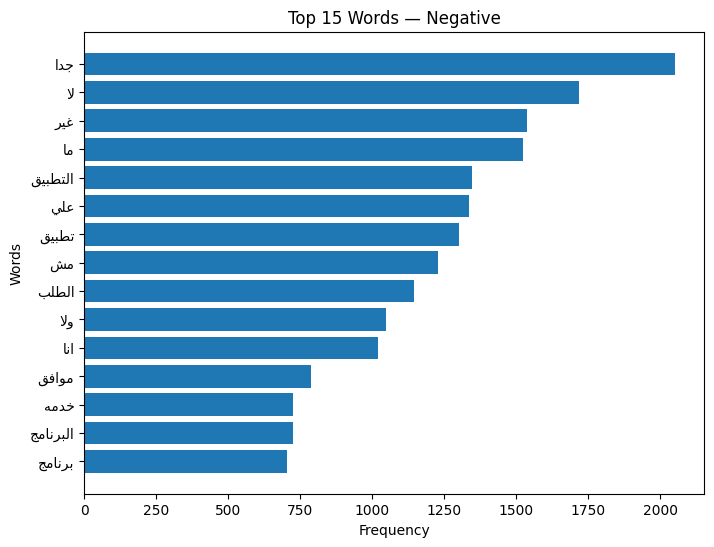

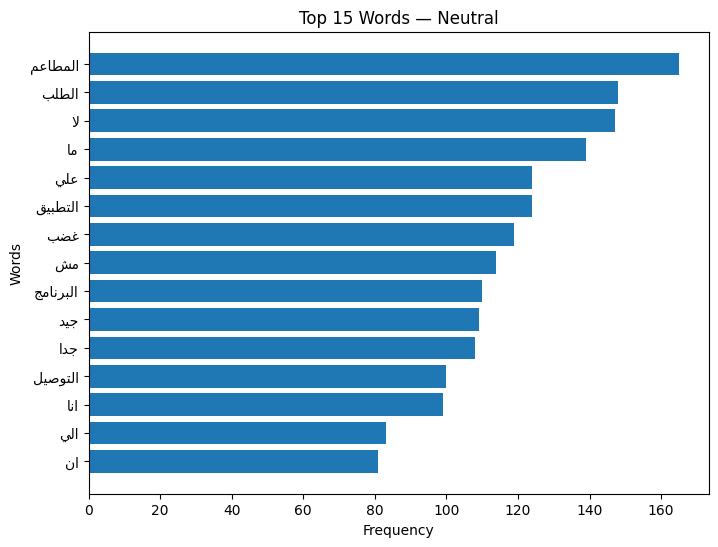

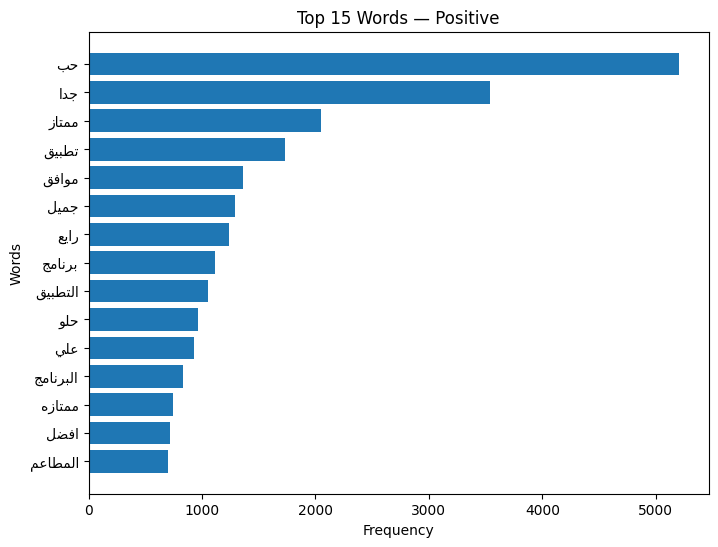

In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

BIDI_CONTROLS = re.compile(r'[\u200e\u200f\u202a-\u202e\u2066-\u2069]')

def get_word_freqs(df, label_value):
    words = " ".join(
        df.loc[df["label"] == label_value, "clean_text"]
    ).split()
    return Counter(words)

def plot_top_words(df, label_value, label_name, top_n=15):

    freqs = get_word_freqs(df, label_value)

    # Get most frequent words
    top_words = freqs.most_common(top_n)

    words = []
    counts = []

    for word, count in top_words:
        word = BIDI_CONTROLS.sub("", word)
        word = get_display(arabic_reshaper.reshape(word))
        words.append(word)
        counts.append(count)

    plt.figure(figsize=(8, 6))

    plt.barh(words, counts)

    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.title(f"Top {top_n} Words — {label_name}")

    plt.gca().invert_yaxis()

    plt.show()

label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

for val, name in label_map.items():
    plot_top_words(df, val, name)

In [ ]:
MAX_VOCAB = 20000
MAX_LEN = 40

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])
vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print("Vocabulary size:", vocab_size)

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values
print("Final input shape:", X.shape)

Vocabulary size: 20000
Final input shape: (31094, 40)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#Experiment 1

In [ ]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN),
    Bidirectional(GRU(64)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

{0: np.float64(0.930497886507313), 1: np.float64(7.038766270514997), 2: np.float64(0.5607782136255016)}
Epoch 1/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.6992 - loss: 0.8092 - val_accuracy: 0.7126 - val_loss: 0.6998
Epoch 2/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7967 - loss: 0.5699 - val_accuracy: 0.7605 - val_loss: 0.6137
Epoch 3/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8605 - loss: 0.4009 - val_accuracy: 0.7331 - val_loss: 0.7355
Epoch 4/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8964 - loss: 0.2925 - val_accuracy: 0.7387 - val_loss: 0.7745
Epoch 5/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9221 - loss: 0.2267 - val_accuracy: 0.7697 - val_loss: 0.8058


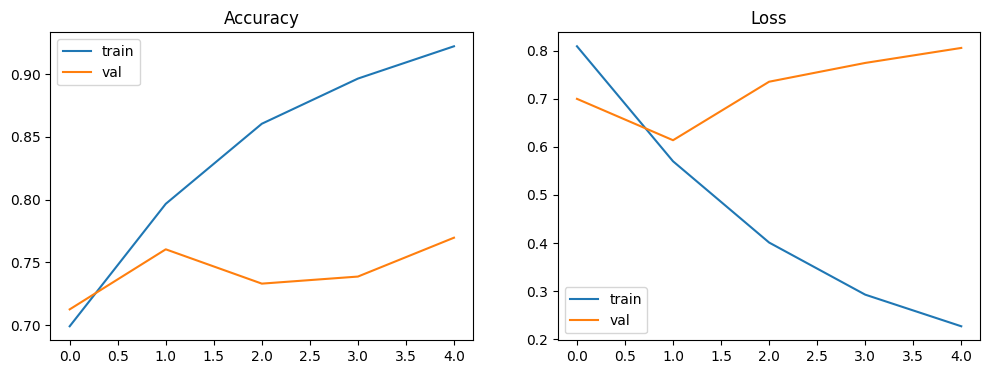

In [ ]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)  #class 1 (neutral) will get largest weight

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    batch_size=32,
    epochs=5,
    class_weight=class_weight_dict
)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.show()

195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7644 - loss: 0.8120
Test accuracy: 0.7644315958023071
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


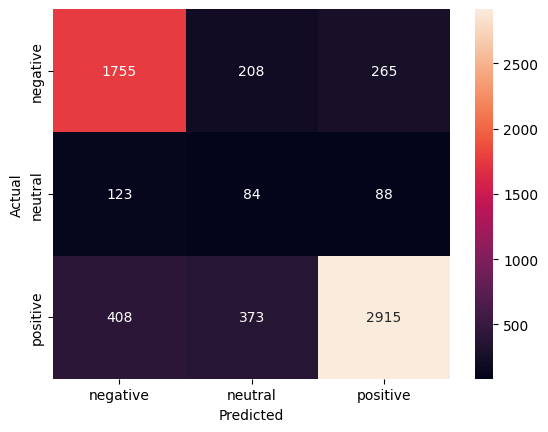

              precision    recall  f1-score   support

    negative       0.77      0.79      0.78      2228
     neutral       0.13      0.28      0.17       295
    positive       0.89      0.79      0.84      3696

    accuracy                           0.76      6219
   macro avg       0.60      0.62      0.60      6219
weighted avg       0.81      0.76      0.78      6219



In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test accuracy:", acc)

y_pred = np.argmax(model.predict(X_test), axis=1)

labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.show()

print(classification_report(y_test, y_pred, target_names=labels))

#Experiment 2

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Bidirectional, Dropout, Dense

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN),

    Bidirectional(SimpleRNN(64)),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

{0: np.float64(0.930497886507313), 1: np.float64(7.038766270514997), 2: np.float64(0.5607782136255016)}
Epoch 1/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9628 - loss: 0.0955 - val_accuracy: 0.7685 - val_loss: 1.0875
Epoch 2/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9640 - loss: 0.0858 - val_accuracy: 0.7757 - val_loss: 1.1773
Epoch 3/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9625 - loss: 0.0890 - val_accuracy: 0.6748 - val_loss: 1.3160
Epoch 4/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9598 - loss: 0.0967 - val_accuracy: 0.7444 - val_loss: 1.2280
Epoch 5/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9641 - loss: 0.0908 - val_accuracy: 0.7134 - val_loss: 1.2273


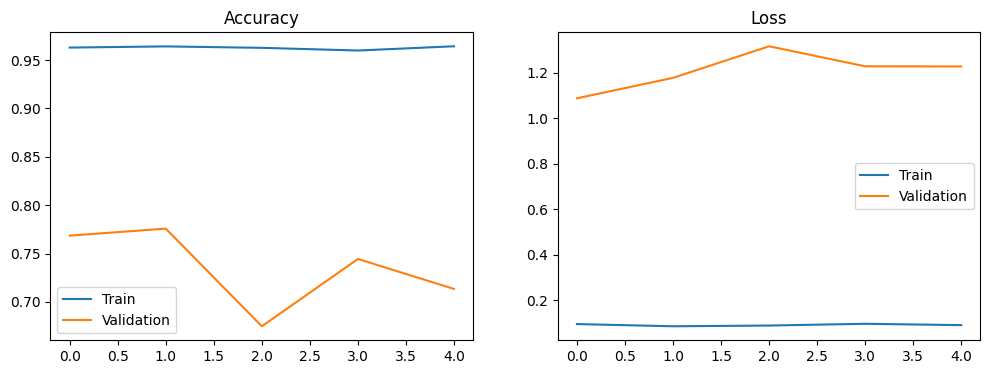

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print(class_weight_dict)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    batch_size=32,
    epochs=5,
    class_weight=class_weight_dict
)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7170 - loss: 1.2013
Test Accuracy: 0.7169963121414185
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


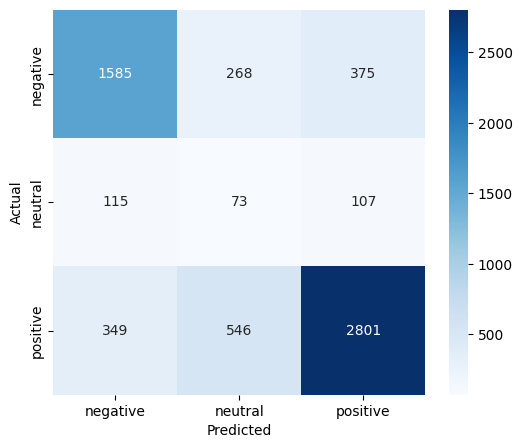

              precision    recall  f1-score   support

    negative       0.77      0.71      0.74      2228
     neutral       0.08      0.25      0.12       295
    positive       0.85      0.76      0.80      3696

    accuracy                           0.72      6219
   macro avg       0.57      0.57      0.56      6219
weighted avg       0.79      0.72      0.75      6219



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

loss, acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", acc)

y_pred = np.argmax(model.predict(X_test), axis=1)

labels = ['negative', 'neutral', 'positive']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred, target_names=labels))

#Experiment 3

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN),

    LSTM(64),

    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

{0: np.float64(0.930497886507313), 1: np.float64(7.038766270514997), 2: np.float64(0.5607782136255016)}
Epoch 1/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.5857 - loss: 1.0298 - val_accuracy: 0.7974 - val_loss: 0.8891
Epoch 2/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7625 - loss: 0.9294 - val_accuracy: 0.7733 - val_loss: 0.7776
Epoch 3/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7549 - loss: 0.7930 - val_accuracy: 0.6877 - val_loss: 0.7521
Epoch 4/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8129 - loss: 0.6675 - val_accuracy: 0.7010 - val_loss: 0.8542
Epoch 5/5
700/700 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8153 - loss: 0.5677 - val_accuracy: 0.6768 - val_loss: 0.7993


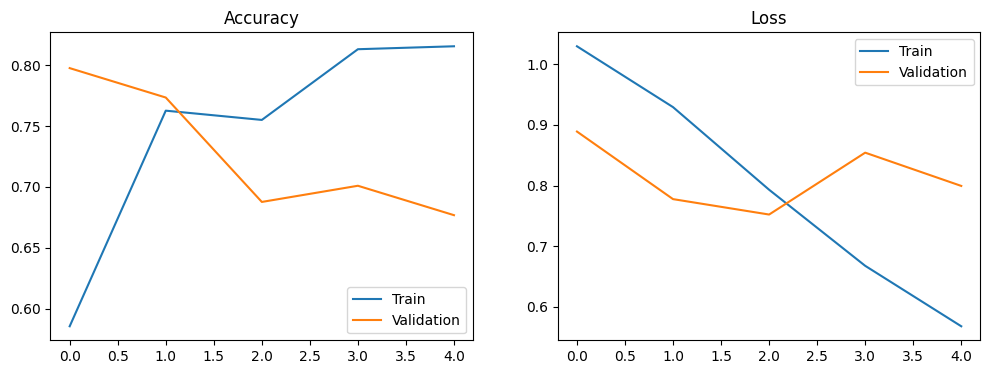

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    batch_size=32,
    epochs=5,
    class_weight=class_weight_dict
)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6696 - loss: 0.8172
Test Accuracy: 0.6695610284805298
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


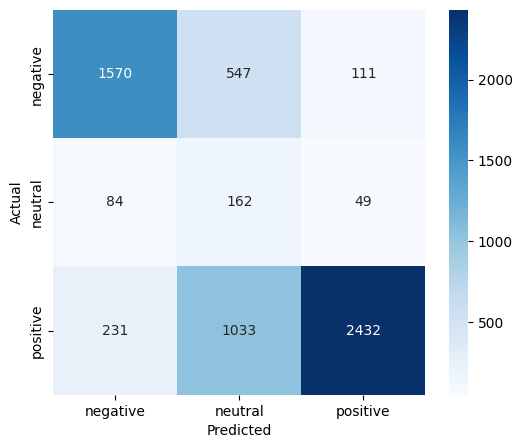

              precision    recall  f1-score   support

    negative       0.83      0.70      0.76      2228
     neutral       0.09      0.55      0.16       295
    positive       0.94      0.66      0.77      3696

    accuracy                           0.67      6219
   macro avg       0.62      0.64      0.57      6219
weighted avg       0.86      0.67      0.74      6219



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

y_pred = np.argmax(model.predict(X_test), axis=1)

labels = ['negative', 'neutral', 'positive']

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred, target_names=labels))

#Experiment 4

In [ ]:
from sklearn.utils import resample
import numpy as np
import pandas as pd

train_idx = np.arange(len(y_train))
neg_idx = train_idx[y_train == 0]
neu_idx = train_idx[y_train == 1]
pos_idx = train_idx[y_train == 2]

ratio = 3
target_size = len(neu_idx) * ratio

neg_down = resample(neg_idx, replace=False, n_samples=min(len(neg_idx), target_size), random_state=42)
pos_down = resample(pos_idx, replace=False, n_samples=min(len(pos_idx), target_size), random_state=42)

combined_idx = np.concatenate([neg_down, neu_idx, pos_down])
np.random.shuffle(combined_idx)

X_train_bal = X_train[combined_idx]
y_train_bal = y_train[combined_idx]

print(pd.Series(y_train_bal).value_counts())

2    3534
0    3534
1    1178
Name: count, dtype: int64


In [ ]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(GRU(64, dropout=0.2, recurrent_dropout=0.2)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

history = model.fit(
    X_train_bal, y_train_bal,
    validation_split=0.1,
    batch_size=32,
    epochs=15,
    callbacks=[early_stop, reduce_lr]

)

Epoch 1/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 69s 258ms/step - accuracy: 0.6465 - loss: 0.8014 - val_accuracy: 0.7261 - val_loss: 0.6740 - learning_rate: 0.0010
Epoch 2/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 60s 260ms/step - accuracy: 0.7829 - loss: 0.5544 - val_accuracy: 0.7370 - val_loss: 0.6675 - learning_rate: 0.0010
Epoch 3/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 83s 265ms/step - accuracy: 0.8485 - loss: 0.4224 - val_accuracy: 0.7115 - val_loss: 0.7174 - learning_rate: 0.0010
Epoch 4/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 59s 254ms/step - accuracy: 0.8906 - loss: 0.3100 - val_accuracy: 0.7236 - val_loss: 0.8157 - learning_rate: 0.0010
Epoch 5/15
232/232 ━━━━━━━━━━━━━━━━━━━━ 58s 250ms/step - accuracy: 0.9240 - loss: 0.2283 - val_accuracy: 0.7042 - val_loss: 0.9217 - learning_rate: 5.0000e-04


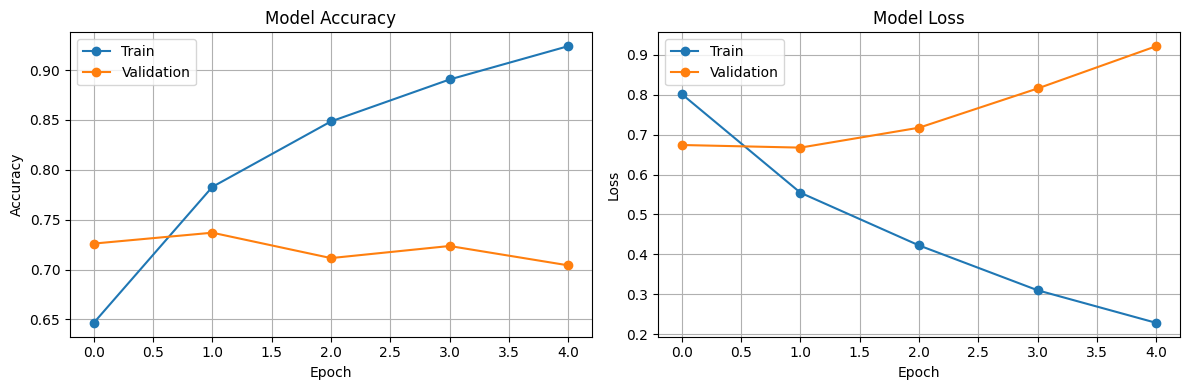

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], marker="o", label="Train")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], marker="o", label="Train")
plt.plot(history.history["val_loss"], marker="o", label="Validation")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

195/195 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.8050 - loss: 0.5251
Test Accuracy: 0.8049525618553162
195/195 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step


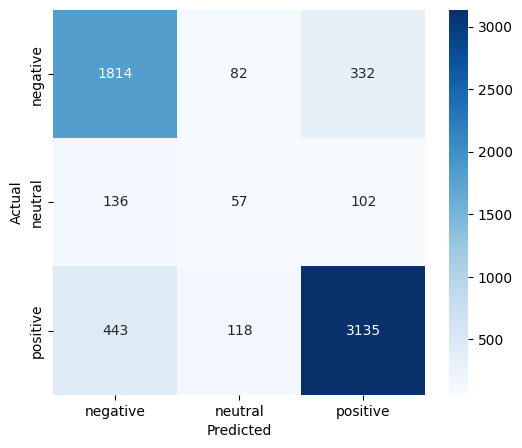

              precision    recall  f1-score   support

    negative       0.76      0.81      0.79      2228
     neutral       0.22      0.19      0.21       295
    positive       0.88      0.85      0.86      3696

    accuracy                           0.80      6219
   macro avg       0.62      0.62      0.62      6219
weighted avg       0.80      0.80      0.80      6219



In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

y_pred = np.argmax(model.predict(X_test), axis=1)

labels = ["negative", "neutral", "positive"]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred, target_names=labels))

#Experiment 5

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df['clean_text'])
y = df['label'].values

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (31094, 20000)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
import numpy as np
from sklearn.utils import resample
import scipy.sparse as sp

train_idx = np.arange(X_train.shape[0])
neg_idx = train_idx[y_train == 0]
neu_idx = train_idx[y_train == 1]
pos_idx = train_idx[y_train == 2]

ratio = 3  # tune this: try 1, 3, 5
target_size = len(neu_idx) * ratio

neg_down = resample(neg_idx, replace=False, n_samples=min(len(neg_idx), target_size), random_state=42)
pos_down = resample(pos_idx, replace=False, n_samples=min(len(pos_idx), target_size), random_state=42)

combined_idx = np.concatenate([neg_down, neu_idx, pos_down])
np.random.shuffle(combined_idx)

X_train_bal = X_train[combined_idx]
y_train_bal = y_train[combined_idx]

print(pd.Series(y_train_bal).value_counts())

2    3534
0    3534
1    1178
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import time

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced_subsample',  # extra help on top of downsampling, mild not extreme
    n_jobs=-1,
    random_state=42
)

start = time.time()
rf.fit(X_train_bal, y_train_bal)
rf_train_time = time.time() - start
print(f"Trained in {rf_train_time:.1f}s")

Trained in 25.9s


Test accuracy: 0.7528541566168194


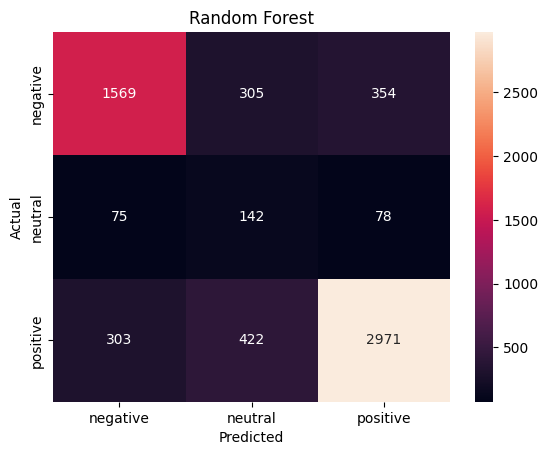

              precision    recall  f1-score   support

    negative       0.81      0.70      0.75      2228
     neutral       0.16      0.48      0.24       295
    positive       0.87      0.80      0.84      3696

    accuracy                           0.75      6219
   macro avg       0.61      0.66      0.61      6219
weighted avg       0.82      0.75      0.78      6219



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred_rf = rf.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred_rf))

labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Random Forest'); plt.show()

print(classification_report(y_test, y_pred_rf, target_names=labels))